In [1]:
import torch

# Torch (and PyTorch) PyTorch is one of the most popular frameworks for
#  developing and training machine learning and deep learning models.

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# CUDA (Compute Unified Device Architecture) is a parallel computing platform
# and programming model developed by NVIDIA for their GPUs. CUDA harness the
# highly parallel processing power of GPUs to perform general-purpose computing
# tasks (i.e., tasks beyond traditional graphics rendering).


Using device: cuda


In [2]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(

    # "runwayml/stable-diffusion-v1-5", # SD 1.5 uses CLIP ViT-L as its text encoder, which caps at 77 tokens and treats the prompt more as a bag of weighted concepts than as a sentence. So it responds to comma-separated tags, not natural language, and front-loaded terms carry more weight.

    # "Lykon/dreamshaper-8",   # community fine-tune of SD 1.5 by Lykon,

    "stabilityai/sd-turbo", # It's Stable Diffusion 2.1, it requires num_inference_steps=1, guidance_scale=0.0
    torch_dtype=torch.float16,
    ).to(device)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [ ]:
# prompt = (
#     "summer afternoon in a public park, group of people on the grass, "
#     "others playing pétanque on gravel, picnic tables, tall plane trees, "
#     "warm golden hour backlight, 35mm photograph, shallow depth of field, film grain, detailed"
# )

prompt = (
    "abstract geometric composition, layered overlapping squares and thin lines, "
    "grid drifting out of alignment, three-color palette of black red and cream, "
    "flat vector shapes, risograph print, screenprint texture, Bauhaus poster, "
    "high contrast, clean"
)

# prompt = (
#     "fashion editorial portrait, model in a garment made from cardboard and packing tape, "
#     "visible seams and raw unfinished edges, plastic bags and bubble wrap draped, "
#     "seamless grey studio backdrop, hard directional strobe, deep shadows, "
#     "medium format photograph, sharp detail, muted colors"
# )

negative_prompt = (
    "blurry, lowres, watermark, text, deformed faces, extra limbs, "
    "bad anatomy, extra fingers, cartoon, illustration, oversaturated"
) # This is what the model steers away from.


image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    generator=torch.Generator(device).manual_seed(11001), # change the seed!
    num_inference_steps=1, guidance_scale=0.0
).images[0]

image

In [ ]:
# There are many, many models available. Always check the model card's example call rather than assuming your existing arguments carry over.
from diffusers import DiffusionPipeline

model_id = "segmind/tiny-sd"  # or any other compatible model
pipe = DiffusionPipeline.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    use_safetensors=False,
    ).to("cuda")

In [ ]:
# prompt = "A generative abstract image composed of layered geometric forms, emergent symmetry, controlled randomness, limited palette of three colors, no figurative elements, visual structure suggests algorithmic repetition and drift."

prompt = "An image as if perceived by a non-human sensing system: partial occlusions, uneven resolution, ambiguous scale, artifacts suggesting compression or reconstruction rather than human vision."

pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

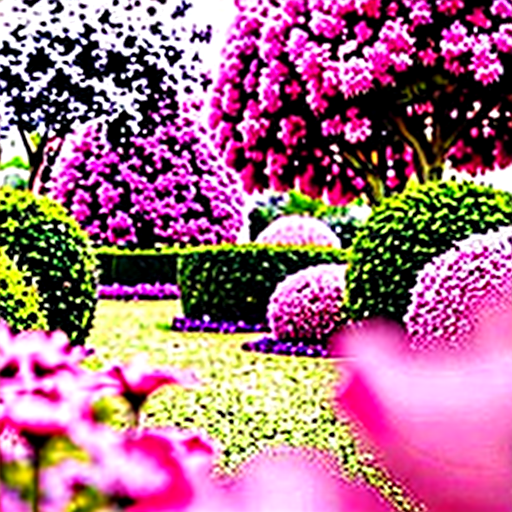

Saved: garden_image_1.png


  0%|          | 0/50 [00:00<?, ?it/s]

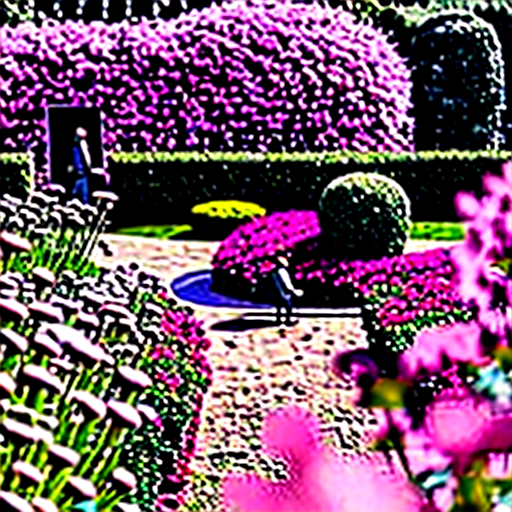

Saved: garden_image_2.png


  0%|          | 0/50 [00:00<?, ?it/s]

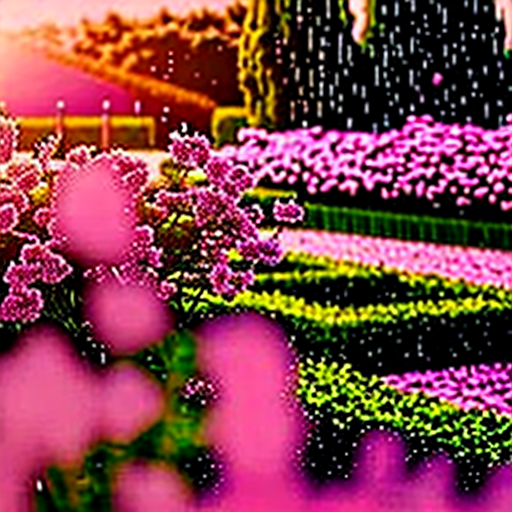

Saved: garden_image_3.png


In [5]:
# Three connected prompts
prompts = [
    "An abstract artistic garden filled with beautiful pink flowers, soft lighting, dreamy atmosphere, no people",

    "An abstract artistic garden filled with the same beautiful pink flowers, with a gardener carefully tending to the flowers, soft lighting, dreamy atmosphere",

    "An abstract artistic garden filled with the same beautiful pink flowers, with the gardener standing peacefully in the garden at sunset, warm dreamy lighting, magical atmosphere"
]

# Generate and save the three images
for i, prompt in enumerate(prompts, start=1):
    image = pipe(prompt).images[0]

    # Save each image with a different filename
    filename = f"garden_image_{i}.png"
    image.save(filename)

    # Display the generated image
    display(image)

    print(f"Saved: {filename}")

generate an abstract image of flowers
